In [6]:
#Libraries import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('titanic.csv')

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
#Explore and clean data are:-
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
# Missing value handle
median_age = df['Age'].median()

In [14]:
df['Age'] = df['Age'].fillna(median_age)

In [15]:
# Verify that missing ages are now fixed
print(f"\nMissing values in 'Age' after fixing: {df['Age'].isnull().sum()}")


Missing values in 'Age' after fixing: 0


In [17]:
# Calculate survival rate by gender
survival_by_gender = df.groupby('Sex')['Survived'].mean() * 100
print(survival_by_gender)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [18]:
# Calculate survival rate by passenger class (Pclass)
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
print(survival_by_class)


Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [19]:
#Survival rate by age group 
bins = [0, 12, 19, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [20]:
survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100
print(survival_by_age)

AgeGroup
Child     57.971014
Teen      41.052632
Adult     36.519258
Senior    26.923077
Name: Survived, dtype: float64


C:\Users\Saurabh\AppData\Local\Temp\ipykernel_9392\696192742.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100


In [21]:
# Visiualization
plt.figure(figsize=(18, 5))

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

BAR CHART


C:\Users\Saurabh\AppData\Local\Temp\ipykernel_9392\1130846495.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='pastel')


Text(0, 0.5, 'Survival Rate (0 = Died, 1 = Survived)')

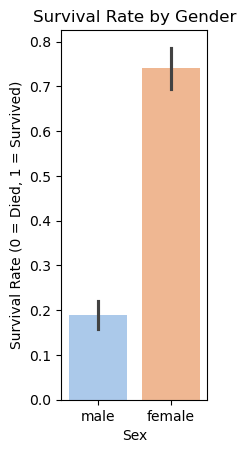

In [30]:
#Bar Chart
print("BAR CHART")
plt.subplot(1, 3, 1)
sns.barplot(x='Sex', y='Survived', data=df, palette='pastel')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate (0 = Died, 1 = Survived)')


C:\Users\Saurabh\AppData\Local\Temp\ipykernel_9392\1479070064.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='pastel')


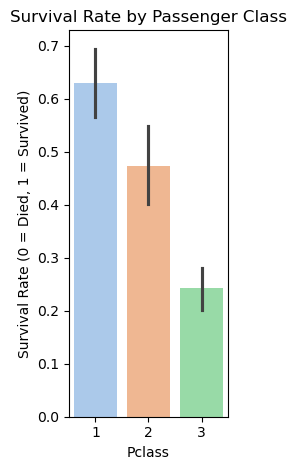

In [31]:
plt.subplot(1, 3, 2)
sns.barplot(x='Pclass', y='Survived', data=df, palette='pastel')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate (0 = Died, 1 = Survived)')
# Show all plots
plt.tight_layout()
plt.show()

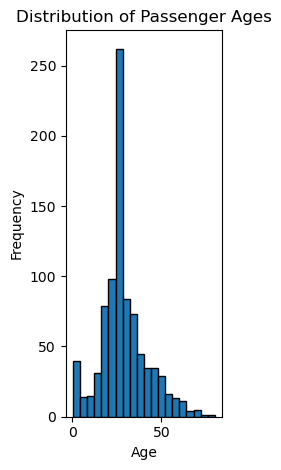

In [27]:
#Histogram
plt.subplot(1, 3, 3)
df['Age'].plot(kind='hist', bins=20, title='Distribution of Passenger Ages', edgecolor='black')
plt.xlabel('Age')
# Show all plots
plt.tight_layout()
plt.show()